In [12]:
import pandas as pd
import numpy as np

num_samples = 1000
print(f"Number of samples set to: {num_samples}")

Number of samples set to: 1000


In [13]:
vehicle_count = np.random.randint(50, 1000, num_samples)
average_speed = np.random.uniform(10, 80, num_samples).round(2)
traffic_signal_wait_time = np.random.uniform(0, 300, num_samples).round(2)
road_type = np.random.choice(['highway', 'arterial', 'residential', 'collector'], num_samples)
weather_conditions = np.random.choice(['clear', 'rainy', 'foggy', 'snowy'], num_samples)
accident_occurrence = np.random.choice([0, 1], num_samples, p=[0.95, 0.05]) # 5% chance of accident
time_of_day = np.random.choice(['morning_rush', 'daytime', 'evening_rush', 'night'], num_samples)

print("Synthetic data generated for all features.")

Synthetic data generated for all features.


In [14]:
congestion_level = []
for i in range(num_samples):
    # Factors contributing to high congestion
    high_congestion_factors = 0
    if vehicle_count[i] > 700: high_congestion_factors += 1
    if average_speed[i] < 30: high_congestion_factors += 1
    if traffic_signal_wait_time[i] > 180: high_congestion_factors += 1
    if time_of_day[i] in ['morning_rush', 'evening_rush']: high_congestion_factors += 1
    if accident_occurrence[i] == 1: high_congestion_factors += 2 # Higher impact
    if road_type[i] in ['highway', 'arterial']: high_congestion_factors += 1

    # Factors contributing to low congestion
    low_congestion_factors = 0
    if vehicle_count[i] < 300: low_congestion_factors += 1
    if average_speed[i] > 60: low_congestion_factors += 1
    if traffic_signal_wait_time[i] < 60: low_congestion_factors += 1
    if time_of_day[i] in ['night']: low_congestion_factors += 1
    if accident_occurrence[i] == 0: low_congestion_factors += 1
    if road_type[i] in ['residential', 'collector']: low_congestion_factors += 1

    if high_congestion_factors >= 4: # Strong indicators for high congestion
        congestion_level.append('high')
    elif low_congestion_factors >= 4: # Strong indicators for low congestion
        congestion_level.append('low')
    else:
        congestion_level.append('medium')

congestion_level = np.array(congestion_level)
print("Synthetic data generated for target variable 'congestion_level'.")

Synthetic data generated for target variable 'congestion_level'.


In [15]:
data = {
    'vehicle_count': vehicle_count,
    'average_speed': average_speed,
    'traffic_signal_wait_time': traffic_signal_wait_time,
    'road_type': road_type,
    'weather_conditions': weather_conditions,
    'accident_occurrence': accident_occurrence,
    'time_of_day': time_of_day,
    'congestion_level': congestion_level
}

df = pd.DataFrame(data)

print("DataFrame created successfully. Displaying the first 5 rows:")
df.head()

DataFrame created successfully. Displaying the first 5 rows:


,vehicle_count,average_speed,traffic_signal_wait_time,road_type,weather_conditions,accident_occurrence,time_of_day,congestion_level
0,746,51.75,258.76,collector,snowy,0,daytime,medium
1,768,71.61,154.15,collector,rainy,0,night,low
2,698,76.42,171.63,arterial,rainy,0,morning_rush,medium
3,229,59.21,106.98,highway,foggy,0,daytime,medium
4,702,39.99,56.31,arterial,rainy,0,daytime,medium


In [22]:
print("Checking for missing values:")
print(df.isnull().sum())

Checking for missing values:
vehicle_count               0
average_speed               0
traffic_signal_wait_time    0
road_type                   0
weather_conditions          0
accident_occurrence         0
time_of_day                 0
congestion_level            0
dtype: int64


In [17]:
categorical_cols = ['road_type', 'weather_conditions', 'time_of_day', 'congestion_level']
numerical_cols = ['vehicle_count', 'average_speed', 'traffic_signal_wait_time', 'accident_occurrence']

# Apply one-hot encoding to categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

print("Categorical columns identified and one-hot encoded.")
print("Numerical columns identified.")
print("Displaying the first 5 rows of the encoded DataFrame:")
df_encoded.head()

Categorical columns identified and one-hot encoded.
Numerical columns identified.
Displaying the first 5 rows of the encoded DataFrame:


,vehicle_count,average_speed,traffic_signal_wait_time,accident_occurrence,road_type_arterial,road_type_collector,road_type_highway,road_type_residential,weather_conditions_clear,weather_conditions_foggy,weather_conditions_rainy,weather_conditions_snowy,time_of_day_daytime,time_of_day_evening_rush,time_of_day_morning_rush,time_of_day_night,congestion_level_high,congestion_level_low,congestion_level_medium
0,746,51.75,258.76,0,False,True,False,False,False,False,False,True,True,False,False,False,False,False,True
1,768,71.61,154.15,0,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False
2,698,76.42,171.63,0,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True
3,229,59.21,106.98,0,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True
4,702,39.99,56.31,0,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("Numerical columns scaled using StandardScaler. Displaying the first 5 rows of the preprocessed DataFrame:")
df_encoded.head()

Numerical columns scaled using StandardScaler. Displaying the first 5 rows of the preprocessed DataFrame:


,vehicle_count,average_speed,traffic_signal_wait_time,accident_occurrence,road_type_arterial,road_type_collector,road_type_highway,road_type_residential,weather_conditions_clear,weather_conditions_foggy,weather_conditions_rainy,weather_conditions_snowy,time_of_day_daytime,time_of_day_evening_rush,time_of_day_morning_rush,time_of_day_night,congestion_level_high,congestion_level_low,congestion_level_medium
0,0.809974,0.395508,1.288674,-0.248135,False,True,False,False,False,False,False,True,True,False,False,False,False,False,True
1,0.891174,1.386378,0.088902,-0.248135,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False
2,0.632811,1.626362,0.289380,-0.248135,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True
3,-1.098218,0.767708,-0.452091,-0.248135,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True
4,0.647575,-0.191230,-1.033226,-0.248135,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True


In [41]:
from sklearn.model_selection import train_test_split

# Identify target columns that were one-hot encoded
target_columns = [col for col in df_encoded.columns if 'congestion_level_' in col]

# Create feature set X by dropping the target columns
X = df_encoded.drop(columns=target_columns)

# Create target variable set y
y = df_encoded[target_columns]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert y_train and y_test from one-hot encoded to single label series
y_train_labels = y_train.idxmax(axis=1).str.replace('congestion_level_', '')
y_test_labels = y_test.idxmax(axis=1).str.replace('congestion_level_', '')

print("Data successfully split into training and testing sets.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("Target labels converted to single-label series.")

Data successfully split into training and testing sets.
Shape of X_train: (800, 16)
Shape of X_test: (200, 16)
Shape of y_train: (800, 3)
Shape of y_test: (200, 3)
Target labels converted to single-label series.


In [42]:
from sklearn.ensemble import GradientBoostingClassifier

# Instantiate Gradient Boosting Classifier model (re-initializing as previous cell was deleted)
gbc_model = GradientBoostingClassifier(random_state=42)

# Train Gradient Boosting Classifier model
print("Training Gradient Boosting Classifier model...")
gbc_model.fit(X_train, y_train_labels)
print("Gradient Boosting Classifier model trained.")

Training Gradient Boosting Classifier model...
Gradient Boosting Classifier model trained.


In [43]:
import pandas as pd

# Get feature importances from the Gradient Boosting Classifier
feature_importances = gbc_model.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances from Gradient Boosting Classifier:\n")
print(importance_df)


Feature Importances from Gradient Boosting Classifier:

                     Feature  Importance
2   traffic_signal_wait_time    0.219708
1              average_speed    0.191872
0              vehicle_count    0.182663
3        accident_occurrence    0.135571
15         time_of_day_night    0.115659
7      road_type_residential    0.042989
5        road_type_collector    0.039870
6          road_type_highway    0.026124
4         road_type_arterial    0.015176
14  time_of_day_morning_rush    0.009763
12       time_of_day_daytime    0.008177
13  time_of_day_evening_rush    0.006859
11  weather_conditions_snowy    0.002781
9   weather_conditions_foggy    0.002011
8   weather_conditions_clear    0.000778
10  weather_conditions_rainy    0.000000


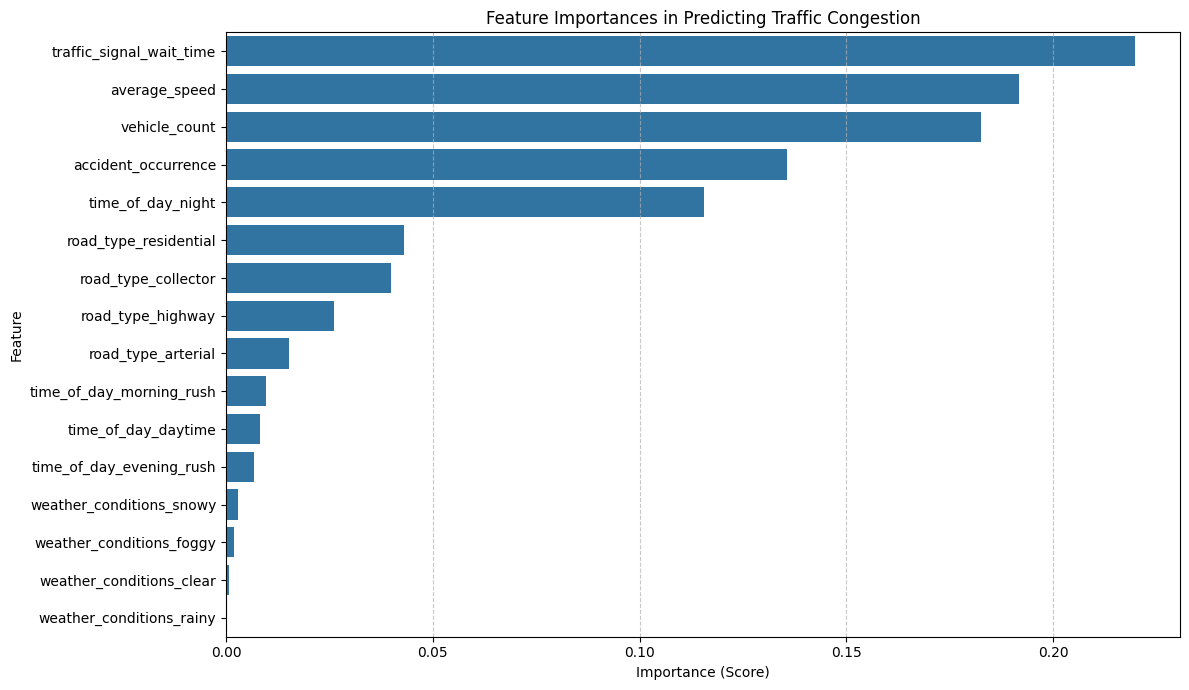

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances in Predicting Traffic Congestion')
plt.xlabel('Importance (Score)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [45]:
import pandas as pd

# Convert congestion_level array to a pandas Series to use value_counts()
congestion_series = pd.Series(congestion_level)

print("Distribution of Congestion Levels:")
print(congestion_series.value_counts())

# Optional: Display as a percentage
print("\nDistribution of Congestion Levels (Percentage):")
print(congestion_series.value_counts(normalize=True) * 100)

Distribution of Congestion Levels:
medium    728
low       147
high      125
Name: count, dtype: int64

Distribution of Congestion Levels (Percentage):
medium    72.8
low       14.7
high      12.5
Name: proportion, dtype: float64


--- Gradient Boosting Classifier Evaluation ---
Accuracy: 0.9500
Precision: 0.9501
Recall: 0.9500
F1-Score: 0.9487

Confusion Matrix:
[[ 22   1   5]
 [  0  25   2]
 [  1   1 143]]


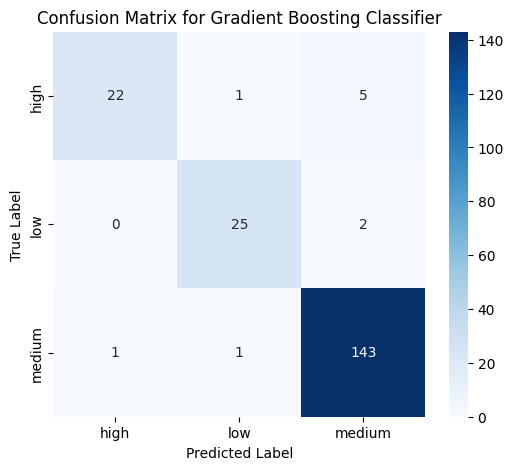

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions using the trained Gradient Boosting Classifier
y_pred = gbc_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test_labels, y_pred)
precision = precision_score(y_test_labels, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test_labels, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test_labels, y_pred, average='weighted', zero_division=0)

# Print metrics
print(f"--- Gradient Boosting Classifier Evaluation ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Generate and print confusion matrix
cm = confusion_matrix(y_test_labels, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=gbc_model.classes_,
            yticklabels=gbc_model.classes_)
plt.title('Confusion Matrix for Gradient Boosting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()